In [3]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("project-droid/DroidCollection")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['Code', 'Generator', 'Generation_Mode', 'Source', 'Language', 'Sampling_Params', 'Rewriting_Params', 'Label', 'Model_Family'],
        num_rows: 846598
    })
    dev: Dataset({
        features: ['Code', 'Generator', 'Generation_Mode', 'Source', 'Language', 'Sampling_Params', 'Rewriting_Params', 'Label', 'Model_Family'],
        num_rows: 105824
    })
    test: Dataset({
        features: ['Code', 'Generator', 'Generation_Mode', 'Source', 'Language', 'Sampling_Params', 'Rewriting_Params', 'Label', 'Model_Family'],
        num_rows: 105826
    })
})


In [ ]:
from datasets import load_dataset
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import time

# LOAD DATA
df_train = pd.DataFrame(dataset['train'])
df_dev   = pd.DataFrame(dataset['dev'])
df_test  = pd.DataFrame(dataset['test'])

print("Train:", df_train.shape)
print("Dev  :", df_dev.shape)
print("Test :", df_test.shape)

# FILTER
target_labels = ['HUMAN_GENERATED', 'MACHINE_GENERATED', 'MACHINE_REFINED']

df_train = df_train[df_train['Language'] == 'Python']
df_dev   = df_dev[df_dev['Language'] == 'Python']
df_test  = df_test[df_test['Language'] == 'Python']

df_train = df_train[df_train['Label'].isin(target_labels)]
df_dev   = df_dev[df_dev['Label'].isin(target_labels)]
df_test  = df_test[df_test['Label'].isin(target_labels)]

# CLEANING
for df in [df_train, df_dev, df_test]:
    df.dropna(subset=['Code'], inplace=True)
    df.drop_duplicates(subset=['Code'], inplace=True)

df_train = df_train[df_train['Code'].str.strip() != '']
df_dev   = df_dev[df_dev['Code'].str.strip() != '']
df_test  = df_test[df_test['Code'].str.strip() != '']

print("After cleaning:")
print("Train:", df_train.shape)
print("Dev  :", df_dev.shape)
print("Test :", df_test.shape)

# LABEL ENCODING
label_map    = {'HUMAN_GENERATED': 0, 'MACHINE_GENERATED': 1, 'MACHINE_REFINED': 2}
target_names = ['human', 'ai', 'hybrid']

df_train['label_enc'] = df_train['Label'].map(label_map)
df_dev['label_enc']   = df_dev['Label'].map(label_map)
df_test['label_enc']  = df_test['Label'].map(label_map)

Train: (846598, 9)
Dev  : (105824, 9)
Test : (105826, 9)
After cleaning:
Train: (233985, 9)
Dev  : (29230, 9)
Test : (29249, 9)


In [ ]:
# STYLOMETRIC FEATURES
def extract_stylometric(code):
    lines     = code.split('\n')
    non_empty = [l for l in lines if l.strip()]

    indents      = [len(l) - len(l.lstrip()) for l in non_empty]
    line_lengths = [len(l) for l in non_empty]
    comment_lines = [l for l in lines if l.strip().startswith('#')]
    identifiers  = re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]*\b', code)
    blank_lines  = [l for l in lines if not l.strip()]
    func_names   = re.findall(r'def\s+([a-zA-Z_][a-zA-Z0-9_]*)', code)
    code_lines   = [l for l in lines if l.strip() and not l.strip().startswith('#')]

    control_keywords = ['if ', 'elif ', 'else:', 'for ', 'while ', 'try:', 'except', 'with ']
    control_count    = sum(code.count(kw) for kw in control_keywords)

    return {
        'indent_consistency'   : np.std(indents) if indents else 0,
        'avg_line_length'      : np.mean(line_lengths) if line_lengths else 0,
        'max_line_length'      : np.max(line_lengths) if line_lengths else 0,
        'comment_density'      : len(comment_lines) / len(lines) if lines else 0,
        'avg_var_length'       : np.mean([len(i) for i in identifiers]) if identifiers else 0,
        'blank_ratio'          : len(blank_lines) / len(lines) if lines else 0,
        'total_lines'          : len(lines),
        'control_count'        : control_count,
        'type_hint_count'      : len(re.findall(r':\s*(int|str|float|bool|list|dict|tuple)', code)),
        'has_docstring'        : int('"""' in code or "'''" in code),
        'avg_func_name_len'    : np.mean([len(f) for f in func_names]) if func_names else 0,
        'num_functions'        : len(func_names),
        'num_imports'          : len(re.findall(r'^\s*(import|from)\s+', code, re.MULTILINE)),
        'comment_to_code_ratio': len(comment_lines) / len(code_lines) if code_lines else 0,
        'list_comp_count'      : len(re.findall(r'\[.+for.+in.+\]', code)),
        'total_chars'          : len(code),
        'unique_ratio'         : len(set(identifiers)) / len(identifiers) if identifiers else 0,
    }

t0 = time.time()
print("Extracting stylometric features...")
stylo_train = pd.DataFrame(df_train['Code'].apply(extract_stylometric).tolist())
stylo_dev   = pd.DataFrame(df_dev['Code'].apply(extract_stylometric).tolist())
stylo_test  = pd.DataFrame(df_test['Code'].apply(extract_stylometric).tolist())
print(f"Done! ({time.time()-t0:.1f}s) | Shape: {stylo_train.shape}")

X_train_s = stylo_train.values
X_test_s  = stylo_test.values
y_train   = df_train['label_enc'].values
y_test    = df_test['label_enc'].values

Extracting stylometric features...
Done! (85.8s) | Shape: (233985, 17)


Stylometric models done! (239.3s)


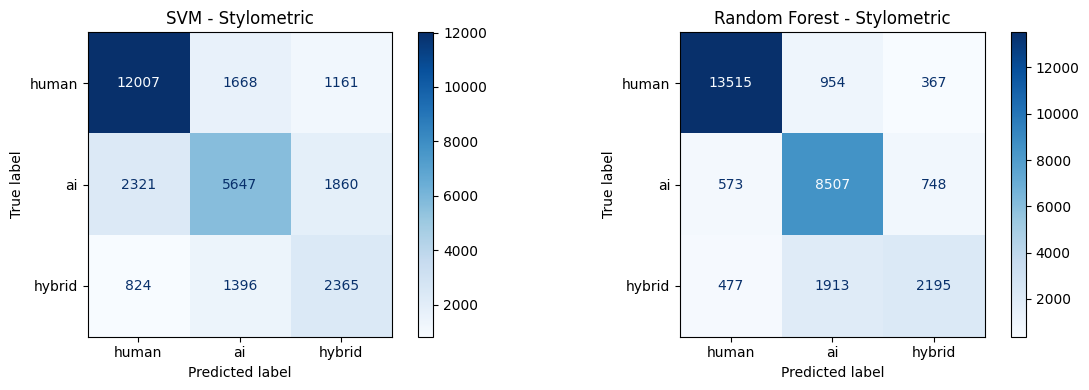


 SVM
Accuracy  : 0.6844
Precision : 0.6886
Recall    : 0.6844
F1-score  : 0.6852
              precision    recall  f1-score   support

       human       0.79      0.81      0.80     14836
          ai       0.65      0.57      0.61      9828
      hybrid       0.44      0.52      0.47      4585

    accuracy                           0.68     29249
   macro avg       0.63      0.63      0.63     29249
weighted avg       0.69      0.68      0.69     29249


 Random Forest
Accuracy  : 0.8280
Precision : 0.8259
Recall    : 0.8280
F1-score  : 0.8231
              precision    recall  f1-score   support

       human       0.93      0.91      0.92     14836
          ai       0.75      0.87      0.80      9828
      hybrid       0.66      0.48      0.56      4585

    accuracy                           0.83     29249
   macro avg       0.78      0.75      0.76     29249
weighted avg       0.83      0.83      0.82     29249



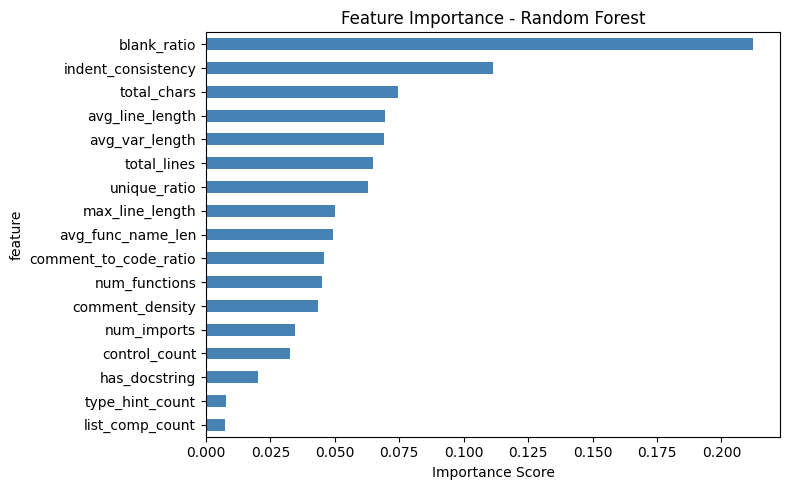

In [ ]:
# MODEL STYLOMETRIC
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, ConfusionMatrixDisplay)

t0 = time.time()
svm = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm.fit(X_train_s, y_train)
y_pred_svm = svm.predict(X_test_s)

rf = RandomForestClassifier(n_estimators=200,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)
print(f"Stylometric models done! ({time.time()-t0:.1f}s)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, ax=ax[0], cmap='Blues',
                                        display_labels=target_names, values_format='d')
ax[0].set_title("SVM - Stylometric")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[1], cmap='Blues',
                                        display_labels=target_names, values_format='d')
ax[1].set_title("Random Forest - Stylometric")
plt.tight_layout()
plt.show()

for name, y_pred in [("SVM", y_pred_svm), ("Random Forest", y_pred_rf)]:
    print("Accuracy  : {:.4f}".format(accuracy_score(y_test, y_pred)))
    print("Precision : {:.4f}".format(precision_score(y_test, y_pred, average='weighted', zero_division=0)))
    print("Recall    : {:.4f}".format(recall_score(y_test, y_pred, average='weighted', zero_division=0)))
    print("F1-score  : {:.4f}".format(f1_score(y_test, y_pred, average='weighted', zero_division=0)))
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

# Feature importance
feat_df = pd.DataFrame({'feature': stylo_train.columns, 'importance': rf.feature_importances_})
feat_df.sort_values('importance', ascending=True).plot(
    kind='barh', x='feature', y='importance', figsize=(8, 5),
    legend=False, color='steelblue')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import StandardScaler

print("\nGPU available:", torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using:", device)

tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
codebert  = AutoModel.from_pretrained("microsoft/codebert-base")
codebert.eval()
codebert  = codebert.to(device)

n_train = 500   
n_test  = 150 

df_train_cb = df_train.groupby('label_enc').sample(n=n_train, random_state=42).reset_index(drop=True)
df_test_cb  = df_test.groupby('label_enc').sample(
    n=min(n_test, df_test['label_enc'].value_counts().min()), random_state=42
).reset_index(drop=True)

print(f"Train sample: {df_train_cb.shape} | Test sample: {df_test_cb.shape}")

def batch_embed(codes, batch_size=32, max_length=128):
    embeddings = []
    total = len(codes)
    for i in range(0, total, batch_size):
        batch  = [str(c)[:800] for c in codes[i:i+batch_size]]
        inputs = tokenizer(batch, return_tensors='pt', truncation=True,
                           max_length=max_length, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = codebert(**inputs)
        cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls)
        print(f"  {min(i+batch_size, total)}/{total}", end='\r')
    print()
    return np.vstack(embeddings)

t0 = time.time()
print("Extracting train embeddings...")
X_train_cb = batch_embed(df_train_cb['Code'].tolist(),
                          batch_size=32 if device=='cuda' else 16)
print("Extracting test embeddings...")
X_test_cb  = batch_embed(df_test_cb['Code'].tolist(),
                          batch_size=32 if device=='cuda' else 16)
print(f"CodeBERT done! ({time.time()-t0:.1f}s)")

y_train_cb = df_train_cb['label_enc'].values
y_test_cb  = df_test_cb['label_enc'].values

# FUSION: CodeBERT + Stylometric 
stylo_train_cb = pd.DataFrame(df_train_cb['Code'].apply(extract_stylometric).tolist())
stylo_test_cb  = pd.DataFrame(df_test_cb['Code'].apply(extract_stylometric).tolist())

scaler_cb             = StandardScaler()
stylo_train_cb_scaled = scaler_cb.fit_transform(stylo_train_cb.values)
stylo_test_cb_scaled  = scaler_cb.transform(stylo_test_cb.values)

X_train_fused = np.hstack([X_train_cb, stylo_train_cb_scaled])
X_test_fused  = np.hstack([X_test_cb,  stylo_test_cb_scaled])
print("Fused shape:", X_train_fused.shape)


GPU available: False
Using: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Train sample: (1500, 10) | Test sample: (450, 10)
Extracting train embeddings...
  1500/1500
Extracting test embeddings...
  450/450
CodeBERT done! (839.6s)
Fused shape: (1500, 785)


In [ ]:
# FUSION: CodeBERT + Stylometric + TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

stylo_train_cb = pd.DataFrame(df_train_cb['Code'].apply(extract_stylometric).tolist())
stylo_test_cb  = pd.DataFrame(df_test_cb['Code'].apply(extract_stylometric).tolist())

# TF-IDF on code tokens
tfidf = TfidfVectorizer(max_features=3000, sublinear_tf=True, ngram_range=(1, 2), analyzer='word')
X_train_tfidf = tfidf.fit_transform(df_train_cb['Code'].tolist()).toarray()
X_test_tfidf  = tfidf.transform(df_test_cb['Code'].tolist()).toarray()

# Scale
scaler_cb             = StandardScaler()
stylo_train_cb_scaled = scaler_cb.fit_transform(stylo_train_cb.values)
stylo_test_cb_scaled  = scaler_cb.transform(stylo_test_cb.values)

X_train_fused = np.hstack([X_train_cb, stylo_train_cb_scaled, X_train_tfidf])
X_test_fused  = np.hstack([X_test_cb,  stylo_test_cb_scaled,  X_test_tfidf])
print("Fused shape:", X_train_fused.shape)

Fused shape: (1500, 3785)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Models done! (25.0s)


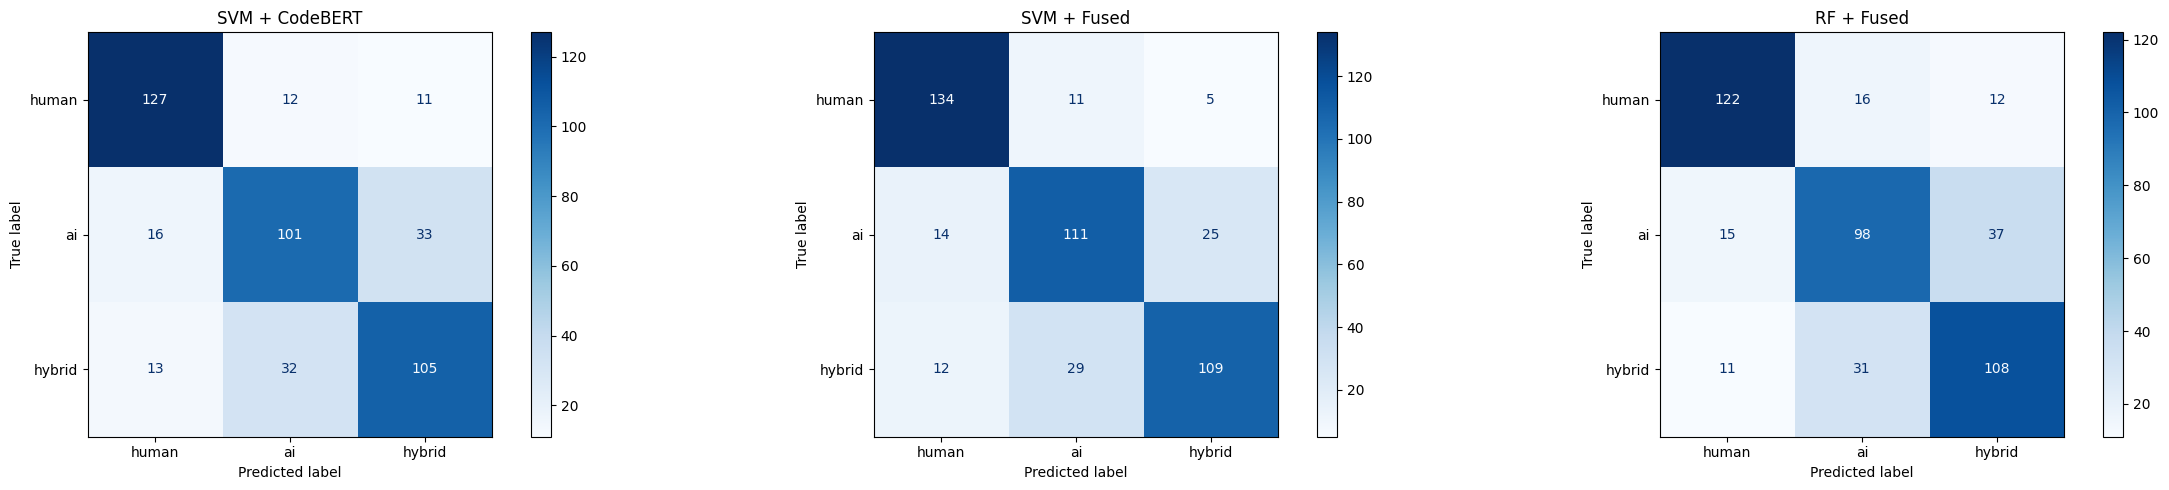


Model                         Acc    Prec     Rec      F1
-------------------------------------------------------
SVM + CodeBERT             0.7400  0.7385  0.7400  0.7391
SVM + Fused                0.7867  0.7856  0.7867  0.7855
RF + Fused                 0.7289  0.7294  0.7289  0.7289

── Detail: SVM + Fused ──
              precision    recall  f1-score   support

       human       0.84      0.89      0.86       150
          ai       0.74      0.74      0.74       150
      hybrid       0.78      0.73      0.75       150

    accuracy                           0.79       450
   macro avg       0.79      0.79      0.79       450
weighted avg       0.79      0.79      0.79       450


── Detail: RF + Fused ──
              precision    recall  f1-score   support

       human       0.82      0.81      0.82       150
          ai       0.68      0.65      0.66       150
      hybrid       0.69      0.72      0.70       150

    accuracy                           0.73       450
   ma

In [ ]:
# MODEL CODEBERT & FUSED
t0 = time.time()

# Baseline CodeBERT only
svm_cb = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm_cb.fit(X_train_cb, y_train_cb)
y_pred_svm_cb = svm_cb.predict(X_test_cb)

# Fused + LinearSVC
svm_fused = LinearSVC(C=1.0, class_weight='balanced', random_state=42, max_iter=2000)
svm_fused.fit(X_train_fused, y_train_cb)
y_pred_fused = svm_fused.predict(X_test_fused)

# Fused + RF
rf_fused = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_fused.fit(X_train_fused, y_train_cb)
y_pred_rf_fused = rf_fused.predict(X_test_fused)

print(f"Models done! ({time.time()-t0:.1f}s)")

# EVALUASI
models_result = {
    'SVM + CodeBERT' : (y_test_cb, y_pred_svm_cb),
    'SVM + Fused'    : (y_test_cb, y_pred_fused),
    'RF + Fused'     : (y_test_cb, y_pred_rf_fused),
}

fig, axes = plt.subplots(1, 3, figsize=(24, 5))
for ax, (name, (y_true, y_pred)) in zip(axes, models_result.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, ax=ax, cmap='Blues',
        display_labels=target_names, values_format='d'
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

print(f"\n{'Model':<25} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}")
print("-" * 55)
for name, (y_true, y_pred) in models_result.items():
    print(f"{name:<25}"
          f" {accuracy_score(y_true, y_pred):>7.4f}"
          f" {precision_score(y_true, y_pred, average='weighted', zero_division=0):>7.4f}"
          f" {recall_score(y_true, y_pred, average='weighted', zero_division=0):>7.4f}"
          f" {f1_score(y_true, y_pred, average='weighted', zero_division=0):>7.4f}")

print("\n── Detail: SVM + Fused ──")
print(classification_report(y_test_cb, y_pred_fused,
      target_names=target_names, zero_division=0))

print("\n── Detail: RF + Fused ──")
print(classification_report(y_test_cb, y_pred_rf_fused,
      target_names=target_names, zero_division=0))

In [77]:
# Input user
def predict_code(code_snippet):
    label_names = {
        0: 'HUMAN_GENERATED',
        1: 'MACHINE_GENERATED',
        2: 'MACHINE_REFINED (Hybrid)'
    }

    stylo          = pd.DataFrame([extract_stylometric(code_snippet)])
    pred_rf        = rf.predict(stylo.values)[0]

    emb            = batch_embed([code_snippet], batch_size=1, max_length=128)
    tfidf_vec      = tfidf.transform([code_snippet]).toarray()
    stylo_scaled   = scaler_cb.transform(stylo.values)
    fused          = np.hstack([emb, stylo_scaled, tfidf_vec])
    pred_svm_fused = svm_fused.predict(fused)[0]

    print("\n")
    print("  HASIL KLASIFIKASI CODE")
    print(f"  {'Model':<25} {'Prediksi'}")
    print(f"  {'-' * 45}")
    print(f"  {'RF  (Stylometric)':<25} {label_names[pred_rf]}")
    print(f"  {'SVM (Fused)':<25} {label_names[pred_svm_fused]}")

    return {
        "RF_Stylometric": label_names[pred_rf],
        "SVM_Fused"     : label_names[pred_svm_fused],
    }

print("Paste code Python,")
print("Ketik END di baris baru untuk selesai.\n")

lines = []

while True:
    try:
        line = input()
    except EOFError:
        break

    if line.strip().upper() == "END":
        break
    lines.append(line)

user_code = "\n".join(lines)

if user_code.strip():
    result = predict_code(user_code)
else:
    print("Tidak ada code yang diinput.")

Paste code Python,
Ketik END di baris baru untuk selesai.

def hitung(data):     res = 0     mn = data[0]     mx = data[0]     for x in data:         res += x         if x < mn: mn = x         if x > mx: mx = x     avg = res/len(data)     # ini buat cari yang di atas rata2     filtered = []     for x in data:         if x > avg: filtered.append(x)     return filtered, avg, mn, mx  data = [3,7,2,9,1,5,8,4,6] hasil, rata, minimum, maximum = hitung(data) print(hasil, rata, minimum, maximum)
End
  1/1


  HASIL KLASIFIKASI CODE
  Model                     Prediksi
  ---------------------------------------------
  RF  (Stylometric)         MACHINE_GENERATED
  SVM (Fused)               HUMAN_GENERATED
